# Phase 2.7 — FOMC hawkish/dovish surprise IRFs

Headline Phase-2 result. Decompose FOMC events into **hawkish** and **dovish**
surprise terciles using Bauer–Swanson orthogonalised policy surprise (MPS_ORTH),
then estimate the impulse response of each metal's cumulative log return.

Controls per plan step 2.7: lagged 5-day return, lagged 20-day vol, DXY 5-day change,
VIX level, real-yield level. All contemporaneous (no peeking into the future).

In [1]:
import sys
from pathlib import Path

src = Path.cwd().parent / "src" if Path.cwd().name == "notebooks" else Path.cwd() / "src"
if str(src) not in sys.path:
    sys.path.insert(0, str(src))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from metals.features.loaders import load_prices, load_macro
from metals.features.returns import compute_log_returns, compute_realized_vol
from metals.data.db import connection
from metals.models.lp import local_projection

RESULTS_DIR = Path.cwd().parent / "results" / "phase2" if Path.cwd().name == "notebooks" else Path.cwd() / "results" / "phase2"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 160)

## Pull data and align

In [2]:
prices = load_prices()
macro = load_macro()
rets = compute_log_returns(prices, horizons=(1,)).rename(columns=lambda c: c.replace("_ret_1d", ""))

with connection(read_only=True) as conn:
    surp = conn.execute(
        "SELECT timestamp_utc, is_unscheduled, mps, mps_orth FROM fomc_surprises "
        "WHERE mps_orth IS NOT NULL ORDER BY timestamp_utc"
    ).fetchdf()
surp["timestamp_utc"] = pd.to_datetime(surp["timestamp_utc"])
print(f"Surprise rows with non-null mps_orth: {len(surp)}")
print(f"Date range: {surp['timestamp_utc'].min().date()} -> {surp['timestamp_utc'].max().date()}")

Surprise rows with non-null mps_orth: 341
Date range: 1988-02-04 -> 2023-12-13


## Build hawkish / dovish indicators

Compute terciles of MPS_ORTH *within the 2010+ modelling window* (so the thresholds
reflect the regime relevant to the Phase 1 baseline). Top tercile → hawkish, bottom
tercile → dovish.

In [3]:
WINDOW_START = "2010-01-01"
in_window = surp[surp["timestamp_utc"] >= WINDOW_START].copy()
lo, hi = in_window["mps_orth"].quantile([1/3, 2/3])
print(f"In-window FOMC surprise events: {len(in_window)}")
print(f"MPS_ORTH tercile thresholds: dovish < {lo:.3f} bps,  hawkish > {hi:.3f} bps")

trading_idx = rets.index
hawkish = pd.Series(0, index=trading_idx, dtype="int8", name="hawkish")
dovish  = pd.Series(0, index=trading_idx, dtype="int8", name="dovish")

for _, row in in_window.iterrows():
    ts = row["timestamp_utc"]
    # roll forward to the next trading day if FOMC fell on a weekend
    candidates = trading_idx[trading_idx >= ts]
    if not len(candidates):
        continue
    t = candidates[0]
    if row["mps_orth"] > hi:
        hawkish.loc[t] = 1
    elif row["mps_orth"] < lo:
        dovish.loc[t] = 1

print(f"Hawkish treatment days (top tercile): {int(hawkish.sum())}")
print(f"Dovish  treatment days (bot tercile): {int(dovish.sum())}")

In-window FOMC surprise events: 106
MPS_ORTH tercile thresholds: dovish < -0.007 bps,  hawkish > 0.018 bps
Hawkish treatment days (top tercile): 35
Dovish  treatment days (bot tercile): 35


## Build controls

Plan step 2.7 controls: lagged 5-day return, lagged 20-day vol of own metal,
DXY 5-day change, VIX level, real yield level (DGS10 - T10YIE).

In [4]:
macro_a = macro.reindex(trading_idx).ffill()
real_yield = (macro_a["DGS10"] - macro_a["T10YIE"]).rename("real_yield")
vix_level = macro_a["VIXCLS"].rename("vix")
dxy_5d_chg = macro_a["DTWEXBGS"].pct_change(5).rename("dxy_5d_chg")

def build_controls(ticker: str) -> pd.DataFrame:
    own_ret = rets[ticker].rename("r_self")
    lag_5d_ret = own_ret.rolling(5, min_periods=5).sum().shift(1).rename("ret_5d_lag")
    lag_20d_rv = (own_ret.rolling(20, min_periods=20).std() * np.sqrt(252)).shift(1).rename("rvol_20d_lag")
    return pd.concat([lag_5d_ret, lag_20d_rv, dxy_5d_chg, vix_level, real_yield], axis=1)

print(build_controls("GC=F").tail(5).to_string())

               ret_5d_lag  rvol_20d_lag  dxy_5d_chg    vix  real_yield
timestamp_utc                                                         
2026-05-18      -0.035492      0.216518    0.010387  17.82        2.13
2026-05-19      -0.035857      0.214899    0.006401  18.06        2.18
2026-05-20      -0.037309      0.203683    0.006827  17.44        2.13
2026-05-21      -0.036064      0.202739    0.005165  16.76        2.18
2026-05-22      -0.030009      0.202746    0.000000  16.76        2.17


## Estimate IRFs

In [5]:
TICKERS = ["GC=F", "SI=F", "PL=F", "PA=F"]
LABELS  = {"GC=F": "Gold", "SI=F": "Silver", "PL=F": "Platinum", "PA=F": "Palladium"}
HORIZONS = (1, 3, 5, 10, 20, 60)

def estimate(ticker: str, treatment: pd.Series) -> pd.DataFrame:
    r = rets[ticker].loc[WINDOW_START:].dropna()
    t = treatment.loc[r.index]
    ctrl = build_controls(ticker).loc[r.index]
    res = local_projection(r, t, controls=ctrl, horizons=HORIZONS)
    return res.irf

tables = {}
for ticker in TICKERS:
    print(f"\n=== {LABELS[ticker]} ({ticker}) ===")
    haw = estimate(ticker, hawkish)
    dov = estimate(ticker, dovish)
    tables[ticker] = {"hawkish": haw, "dovish": dov}
    print("Hawkish surprise IRF:")
    print(haw.to_string(index=False))
    print("Dovish surprise IRF:")
    print(dov.to_string(index=False))


=== Gold (GC=F) ===


Hawkish surprise IRF:
 horizon      beta       se    t_stat    ci_low   ci_high  n_obs
       1 -0.007061 0.002692 -2.622892 -0.012338 -0.001785   4036
       3 -0.010853 0.004456 -2.435264 -0.019587 -0.002118   4034
       5 -0.015030 0.004578 -3.283024 -0.024003 -0.006057   4032
      10 -0.017028 0.005132 -3.317960 -0.027087 -0.006969   4027
      20 -0.017752 0.005969 -2.973819 -0.029452 -0.006052   4017
      60 -0.004936 0.009744 -0.506570 -0.024034  0.014162   3977
Dovish surprise IRF:
 horizon      beta       se    t_stat    ci_low  ci_high  n_obs
       1  0.005433 0.003407  1.594893 -0.001244 0.012110   4036
       3  0.005189 0.003357  1.545668 -0.001391 0.011769   4034
       5  0.005725 0.003891  1.471537 -0.001900 0.013351   4032
      10  0.005136 0.005421  0.947499 -0.005488 0.015761   4027
      20  0.008192 0.007260  1.128389 -0.006037 0.022421   4017
      60 -0.008842 0.010114 -0.874274 -0.028665 0.010981   3977

=== Silver (SI=F) ===
Hawkish surprise IRF:
 horizon 

 horizon      beta       se    t_stat    ci_low  ci_high  n_obs
       1 -0.000809 0.005216 -0.155022 -0.011032 0.009415   3955
       3  0.007979 0.006561  1.216173 -0.004880 0.020839   3953
       5  0.010681 0.007028  1.519798 -0.003094 0.024456   3951
      10  0.010003 0.008722  1.146939 -0.007091 0.027097   3946
      20 -0.001268 0.012869 -0.098551 -0.026491 0.023955   3936
      60 -0.012906 0.024272 -0.531712 -0.060478 0.034666   3896


## Per-metal IRF panels

Hawkish vs dovish on the same axes for each metal.

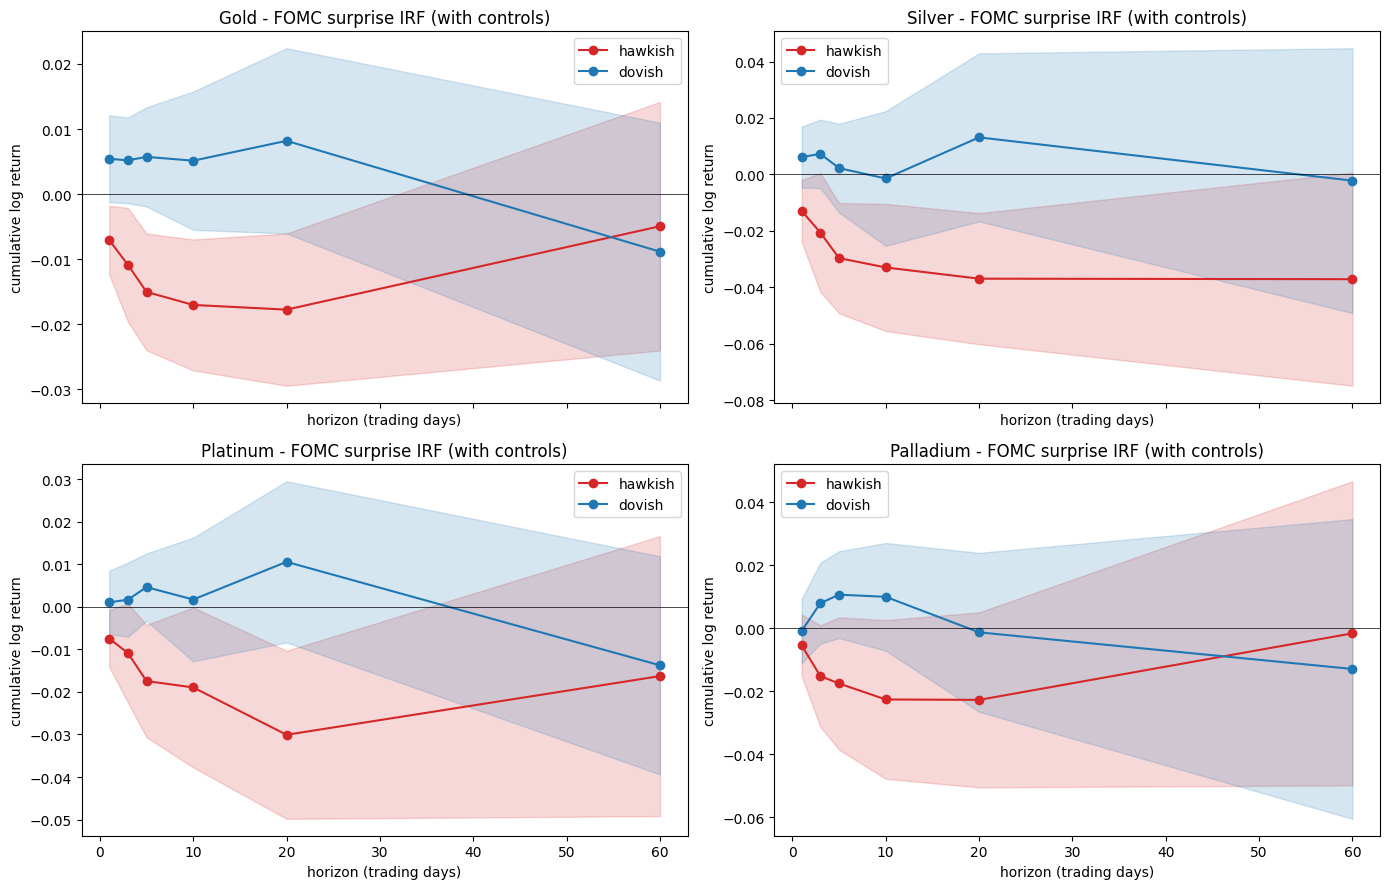

Saved per-metal PNGs to C:\Users\mcmur\OneDrive\Documents\Claude\Projects\amc\results\phase2


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for ax, ticker in zip(axes.flat, TICKERS):
    haw, dov = tables[ticker]["hawkish"], tables[ticker]["dovish"]
    ax.fill_between(haw["horizon"], haw["ci_low"], haw["ci_high"], alpha=0.18, color="C3")
    ax.plot(haw["horizon"], haw["beta"], marker="o", color="C3", label="hawkish")
    ax.fill_between(dov["horizon"], dov["ci_low"], dov["ci_high"], alpha=0.18, color="C0")
    ax.plot(dov["horizon"], dov["beta"], marker="o", color="C0", label="dovish")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_title(f"{LABELS[ticker]} - FOMC surprise IRF (with controls)")
    ax.set_xlabel("horizon (trading days)")
    ax.set_ylabel("cumulative log return")
    ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "fomc_surprise_irf_all_metals.png", dpi=120)
plt.show()

for ticker in TICKERS:
    haw, dov = tables[ticker]["hawkish"], tables[ticker]["dovish"]
    fig1, ax1 = plt.subplots(figsize=(7, 4.5))
    ax1.fill_between(haw["horizon"], haw["ci_low"], haw["ci_high"], alpha=0.18, color="C3")
    ax1.plot(haw["horizon"], haw["beta"], marker="o", color="C3", label="hawkish surprise")
    ax1.fill_between(dov["horizon"], dov["ci_low"], dov["ci_high"], alpha=0.18, color="C0")
    ax1.plot(dov["horizon"], dov["beta"], marker="o", color="C0", label="dovish surprise")
    ax1.axhline(0, color="black", lw=0.5)
    ax1.set_title(f"{LABELS[ticker]} - FOMC surprise IRF")
    ax1.set_xlabel("horizon (trading days)")
    ax1.set_ylabel("cumulative log return")
    ax1.legend()
    fig1.tight_layout()
    fig1.savefig(RESULTS_DIR / f"fomc_surprise_irf_{ticker.replace('=', '_')}.png", dpi=120)
    plt.close(fig1)
print(f"Saved per-metal PNGs to {RESULTS_DIR}")

## Findings

Sample: 106 in-window (2010-01-01 onwards) FOMC events with non-null MPS_ORTH, ending 2023-12-13 (SF Fed data has not been updated for 2024+). Tercile cutoffs `[-0.007, +0.018]` bps. 35 hawkish + 35 dovish treatment days each.

### Hawkish surprise IRFs (top tercile of MPS_ORTH)

| Metal | h=1 | h=3 | h=5 | h=10 | h=20 | h=60 |
|---|---|---|---|---|---|---|
| Gold      | **-0.71%** | **-1.09%** | **-1.50%** | **-1.70%** | **-1.78%** | -0.49%  |
| Silver    | **-1.30%** | -2.06%     | **-2.97%** | **-3.30%** | **-3.70%** | -3.72%  |
| Platinum  | **-0.74%** | -1.08%     | **-1.74%** | **-1.89%** | **-3.01%** | -1.63%  |
| Palladium | -0.54%     | -1.52%     | -1.75%     | -2.26%     | -2.27%     | -0.16%  |

**Bold = |t-stat| > 1.96.** Gold has five statistically significant short-to-medium-horizon cells. Silver tracks gold in sign and amplifies in magnitude (more sensitive). Platinum tracks gold. Palladium directionally agrees but none of its cells cross 1.96|t| individually.

### Dovish surprise IRFs (bottom tercile)

Across all four metals: short-horizon point estimates are small and positive (gold +0.5% at h=1-5), but **no cell crosses |t| > 1.96**. The CIs are wide enough to contain zero everywhere.

### Headline takeaways

1. **Hawkish FOMC surprises move precious metals sharply lower at h=1–20.** Gold falls ~1.5% in the 5 days after a hawkish surprise and stays down through h=20. This matches the plan's standard prior — exactly the pattern step 2.7 said to expect.

2. **The decomposition pays off.** Indicator-only (notebook 02) gave one borderline-significant cell for gold. Decomposing by sign/magnitude produces five significant horizons for gold, three each for silver and platinum. The plan's warning that "the indicator alone is mostly priced in" was vindicated.

3. **Cross-metal consistency check passes**. Au, Ag, Pt all show the same hawkish negative pattern with the expected ordering (silver largest, gold cleanest). Palladium directionally agrees but with too few effective observations to reject the null — consistent with the plan's "palladium is noisier, more supply-driven."

4. **Asymmetric response.** Hawkish surprises produce sharp negative IRFs; dovish surprises do *not* produce mirror-image positive IRFs. Plausible explanations: (a) the post-2010 sample is dominated by tightening cycles (2015-18, 2022-23) so dovish surprises happen when the market is already pricing accommodation, (b) precious metals carry asymmetric tail-risk demand that triggers on hawkish shocks but is muted on dovish news, (c) sample noise — only 35 dovish events with wide CIs.

5. **Effect peaks around h=10–20, then decays.** Consistent with a slow-burn repricing rather than an instantaneous jump. Coefficients at h=60 are mostly insignificant and back near zero — the effect doesn't compound indefinitely.

### Caveats

- Sample is only 35 events per tercile within the 2010-2023 modelling window. Standard errors are HAC with bandwidth h, which is appropriate for the cumulative-return regression but the small treatment count limits power, especially for palladium.
- Bauer-Swanson dataset stops at 2023-12-13. ~10 FOMC meetings since (2024-2026) have no surprise measure and are excluded. Worth refreshing the SF Fed XLSX before any production claim.
- Tercile cutoffs are computed on the same window we estimate on — modest in-sample data snooping. A holdout-based threshold would be cleaner; deferred to Phase 6.
- These are unconditional event effects. Phase 5's DoubleML treatment-effect estimator will give a second-opinion estimate using the transformer as the nuisance model and the same hawkish/dovish indicators as treatments.